# 📊 Notebook 1 — Exploratory Data Analysis & Preprocessing

**Project**: Multi-Step ECG Time-Series Forecasting using Stacked LSTM  
**Author**: Prabhas Avvaru  

---

## Objective
Explore the ECG dataset structure, understand feature distributions, detect
anomalies algorithmically, and prepare clean data for downstream modelling.

### Dataset Overview
| Property | Value |
|---|---|
| Patients | 65 |
| Time-steps per patient | 17 |
| Input features per step | 8 (O1 – O8) |
| Target per step | 1 (Output1 – Output17) |

---

In [59]:
# ── Imports ──────────────────────────────────────────────────
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import (
    load_raw_dataframe, extract_arrays,
    detect_outliers_iqr, impute_outliers, fit_scalers,
    NUM_STEPS, NUM_FEATURES
)

# ── Style ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})

FIGURES = '../figures'
os.makedirs(FIGURES, exist_ok=True)

DATA_PATH = '../data/ecg_raw.csv'
print('Setup complete ✓')

Setup complete ✓


## 1 · Load & Inspect Raw Data

In [60]:
df = load_raw_dataframe(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}):')
print(list(df.columns[:20]), '...')
df.head()

Shape: (65, 153)
Columns (153):
['O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O1.1', 'O2.1', 'O3.1', 'O4.1', 'O5.1', 'O6.1', 'O7.1', 'O8.1', 'O1.2', 'O2.2', 'O3.2', 'O4.2'] ...


,O1,O2,O3,O4,O5,O6,O7,O8,O1.1,O2.1,...,Output8,Output9,Output10,Output11,Output12,Output13,Output14,Output15,Output16,Output17
0,1,2,3,2.0,2.0,108,70,24,1,2,...,26.0,19.0,22.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,4,9,3.0,3.0,90,60,24,3,4,...,16.0,15.0,14.0,14.0,12.0,12.0,10.0,12.0,10.0,12.0
2,1,4,5,2.0,2.0,120,76,24,1,4,...,13.0,16.0,14.0,17.0,16.0,14.0,15.0,14.0,13.0,13.0
3,2,3,5,2.0,2.0,118,70,16,2,3,...,12.0,12.0,12.0,10.0,10.0,9.0,10.0,10.0,10.0,11.0
4,1,3,4,2.0,2.0,170,100,19,1,2,...,22.0,23.0,19.0,13.0,21.0,23.0,28.0,29.0,26.0,18.0


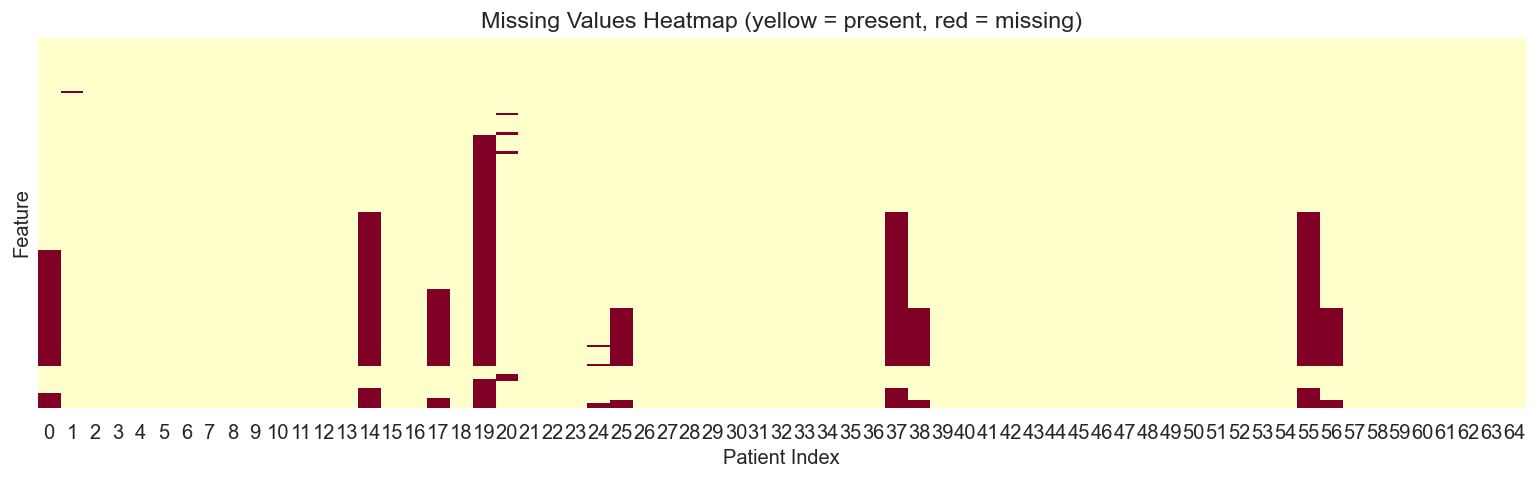

Total missing values (including NT): 506


In [61]:
# ── Missing-value heatmap (before zero-fill) ─────────────────
df_raw = pd.read_csv(DATA_PATH)
df_raw = df_raw.replace('NT', np.nan)
df_raw = df_raw.apply(pd.to_numeric, errors='coerce')

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    df_raw.isna().T, cbar=False, cmap='YlOrRd',
    yticklabels=False, ax=ax
)
ax.set_xlabel('Patient Index')
ax.set_ylabel('Feature')
ax.set_title('Missing Values Heatmap (yellow = present, red = missing)')
fig.savefig(f'{FIGURES}/missing_values_heatmap.png')
plt.show()

total_missing = df_raw.isna().sum().sum()
print(f'Total missing values (including NT): {total_missing}')

## 2 · Extract 3-D Arrays

In [62]:
X, Y = extract_arrays(df)

print(f'X (inputs)  : {X.shape}  →  (patients, time-steps, features)')
print(f'Y (targets) : {Y.shape}  →  (patients, time-steps, 1)')
print(f'\nX range: [{X.min():.2f}, {X.max():.2f}]')
print(f'Y range: [{Y.min():.2f}, {Y.max():.2f}]')

X (inputs)  : (65, 17, 8)  →  (patients, time-steps, features)
Y (targets) : (65, 17, 1)  →  (patients, time-steps, 1)

X range: [0.00, 170.00]
Y range: [0.00, 124.00]


## 3 · Feature Distributions

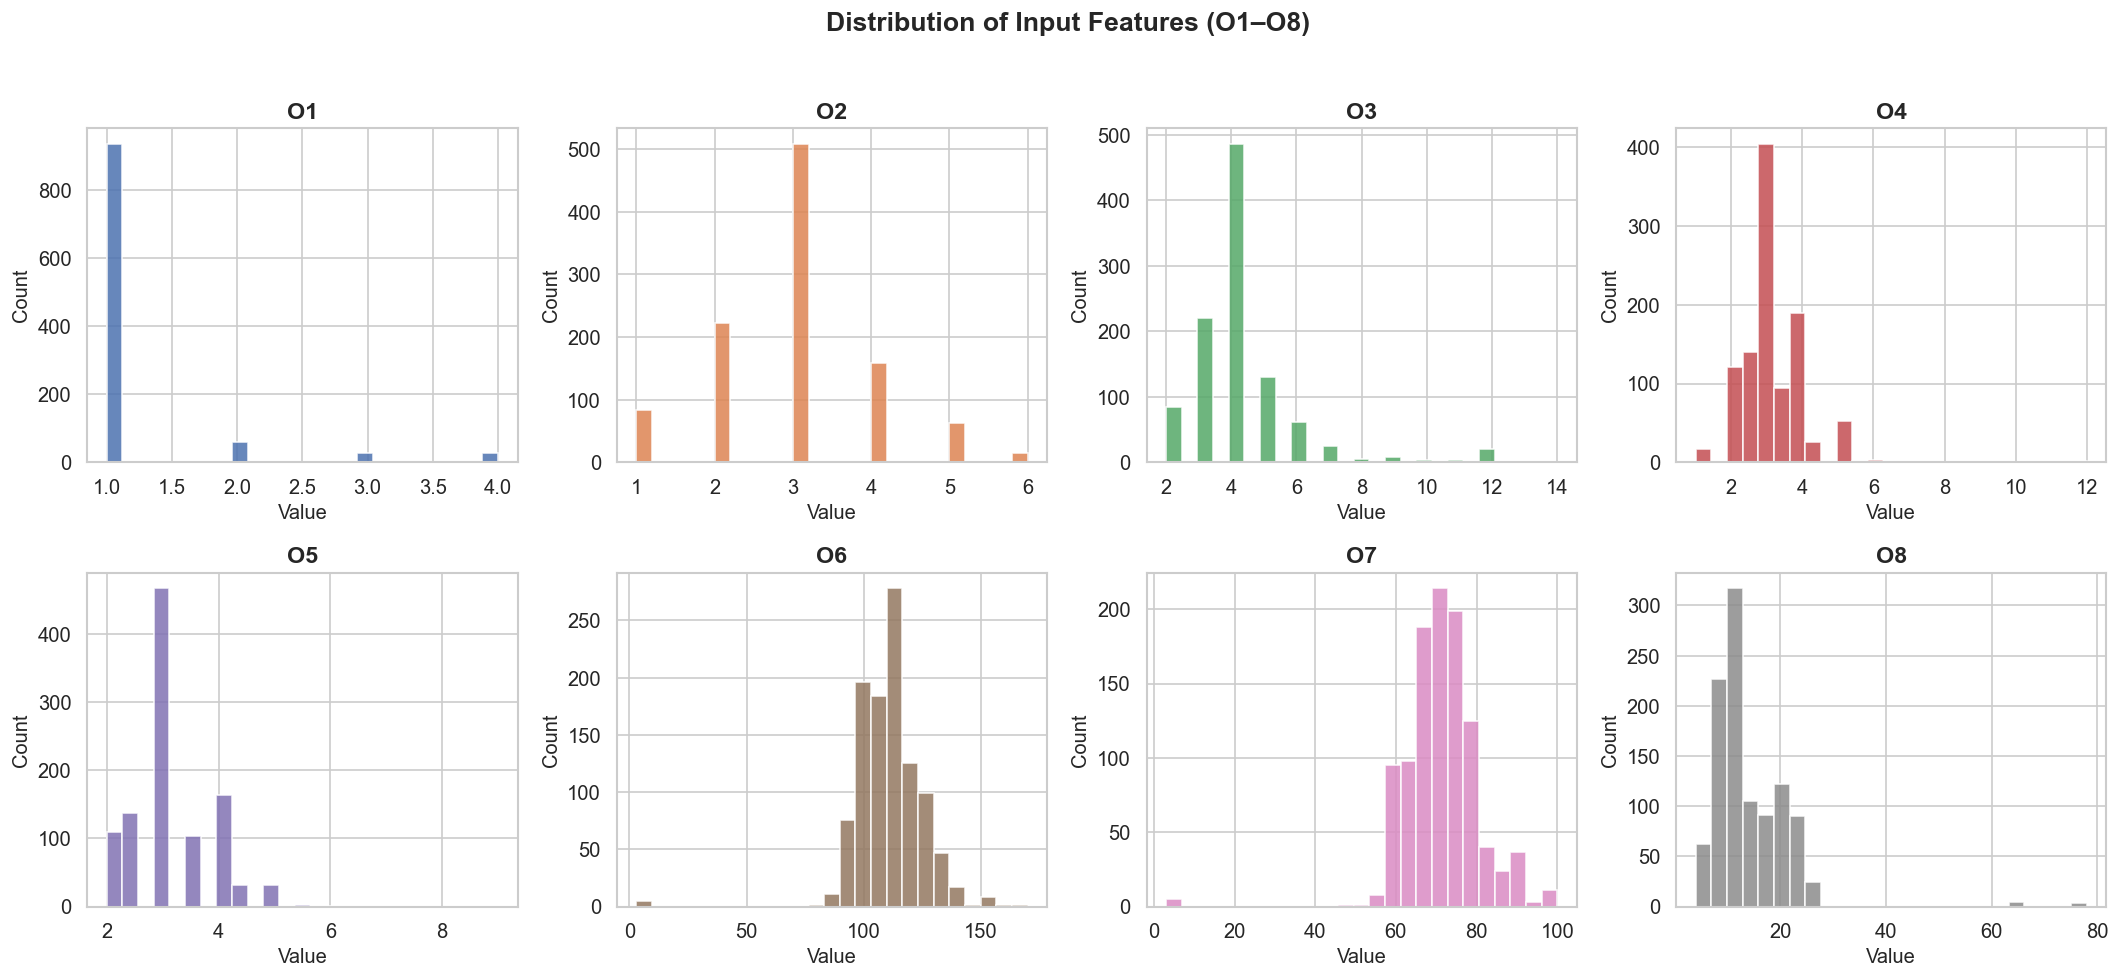

In [63]:
# ── Distribution of each input feature (averaged over time-steps) ──
feature_names = [f'O{i}' for i in range(1, 9)]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for idx, ax in enumerate(axes.flat):
    vals = X[:, :, idx].flatten()
    vals = vals[vals != 0]  # exclude zero-filled missing
    ax.hist(vals, bins=25, color=sns.color_palette('deep')[idx % 8],
            edgecolor='white', alpha=0.85)
    ax.set_title(feature_names[idx], fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

fig.suptitle('Distribution of Input Features (O1–O8)', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f'{FIGURES}/feature_distributions.png')
plt.show()

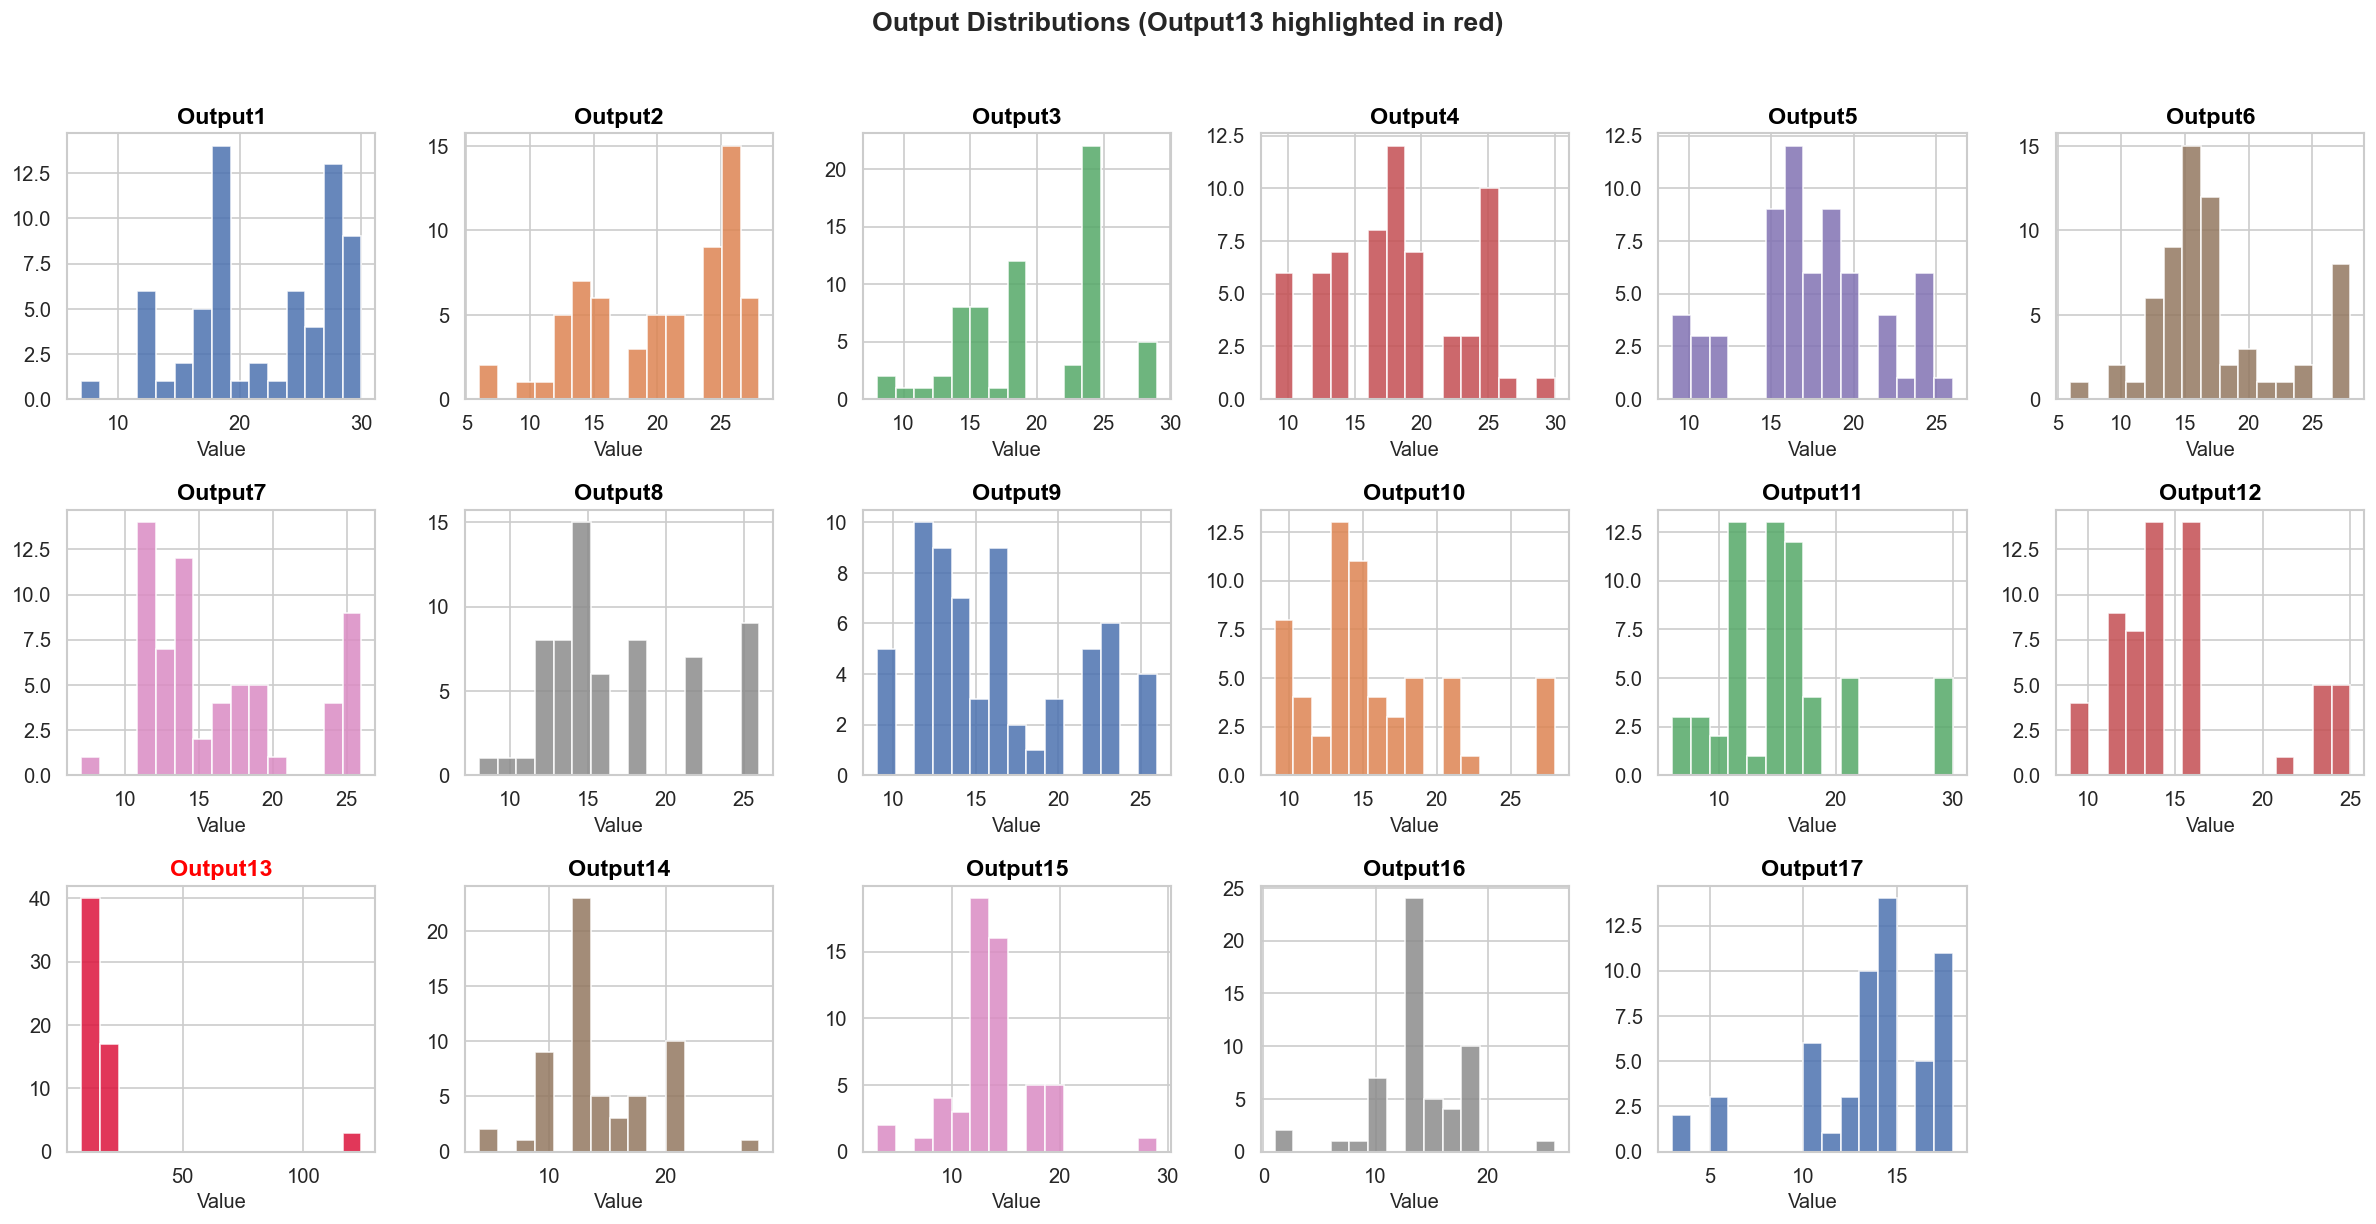

In [64]:
# ── Distribution of output values across all 17 time-steps ──
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes_flat = axes.flat

for step in range(NUM_STEPS):
    ax = axes_flat[step]
    vals = Y[:, step, 0]
    vals_nz = vals[vals != 0]
    color = 'crimson' if step == 12 else sns.color_palette('deep')[step % 8]
    ax.hist(vals_nz, bins=15, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Output{step+1}', fontweight='bold',
                 color='red' if step == 12 else 'black')
    ax.set_xlabel('Value')

# Hide the 18th subplot
axes_flat[17].set_visible(False)

fig.suptitle('Output Distributions (Output13 highlighted in red)', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f'{FIGURES}/output_distributions.png')
plt.show()

## 4 · Sample Patient Trajectories

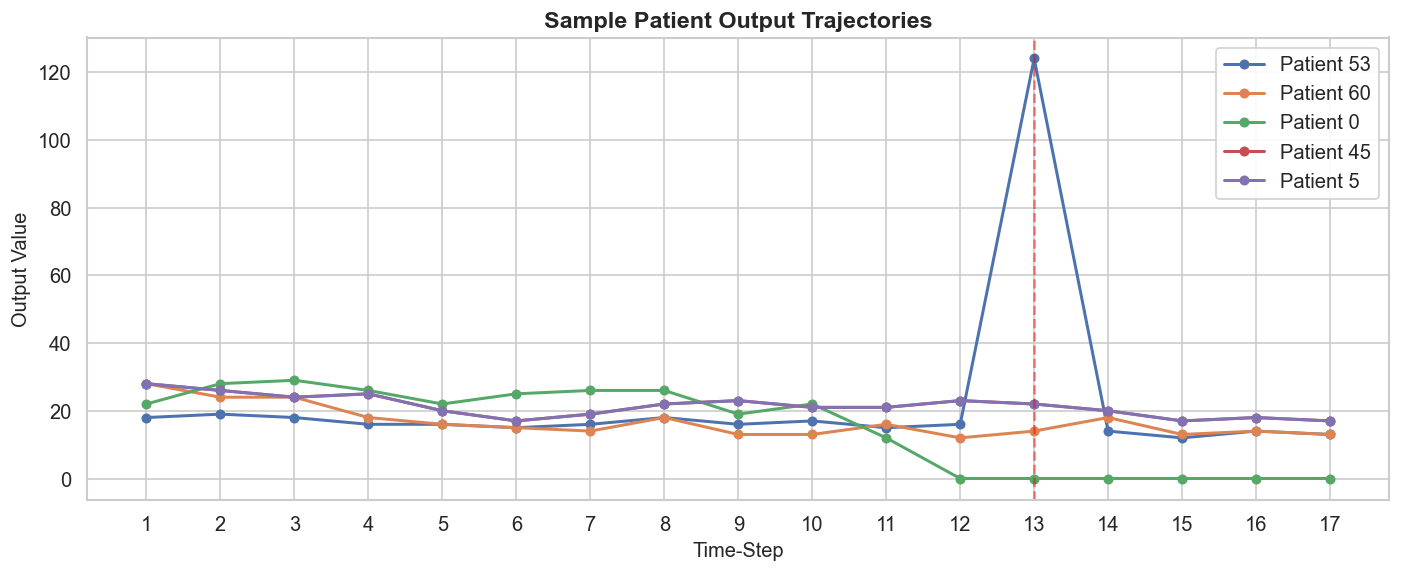

In [65]:
# ── Plot 5 random patient output trajectories ──
np.random.seed(42)
sample_ids = np.random.choice(X.shape[0], 5, replace=False)

fig, ax = plt.subplots(figsize=(14, 5))
for pid in sample_ids:
    ax.plot(range(1, 18), Y[pid, :, 0], marker='o', markersize=5,
            linewidth=1.8, label=f'Patient {pid}')

ax.set_xlabel('Time-Step')
ax.set_ylabel('Output Value')
ax.set_title('Sample Patient Output Trajectories', fontweight='bold')
ax.set_xticks(range(1, 18))
ax.legend(loc='upper right', framealpha=0.9)
ax.axvline(x=13, color='red', linestyle='--', alpha=0.5, label='Output13')
fig.savefig(f'{FIGURES}/patient_trajectories.png')
plt.show()

## 5 · Correlation Analysis

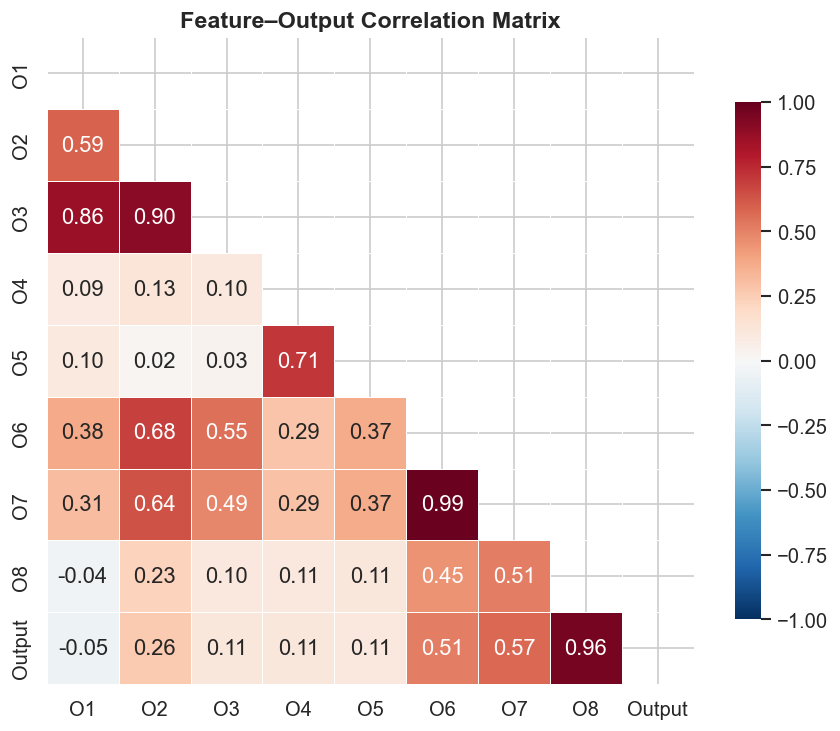

In [66]:
# ── Correlation heatmap: mean features vs mean output ──
X_mean = X.mean(axis=1)  # (65, 8)
Y_mean = Y.mean(axis=1)  # (65, 1)

corr_df = pd.DataFrame(
    np.hstack([X_mean, Y_mean]),
    columns=feature_names + ['Output']
)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(
    corr_df.corr(), mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True, linewidths=0.5,
    ax=ax, vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature–Output Correlation Matrix', fontweight='bold')
fig.savefig(f'{FIGURES}/correlation_heatmap.png')
plt.show()

## 6 · Outlier Detection (Algorithmic — IQR Method)

We scan **all 17 output columns** for outliers using the Inter-Quartile Range
(IQR) method. This ensures we discover anomalies *algorithmically* rather
than hard-coding known values.

In [67]:
# ── Scan all output columns for outliers ──
outlier_summary = []

for step in range(NUM_STEPS):
    col_vals = Y[:, step, 0]
    mask, stats = detect_outliers_iqr(col_vals, k=1.5)
    if stats.get('n_outliers', 0) > 0:
        outlier_summary.append({
            'Column': f'Output{step+1}',
            'N Outliers': stats['n_outliers'],
            'Outlier Values': stats['outlier_values'],
            'IQR': f"{stats['iqr']:.2f}",
            'Upper Fence': f"{stats['upper_fence']:.2f}",
        })

if outlier_summary:
    print('⚠️  Outliers detected:')
    display(pd.DataFrame(outlier_summary))
else:
    print('✓ No outliers detected in any output column.')

⚠️  Outliers detected:


,Column,N Outliers,Outlier Values,IQR,Upper Fence
0,Output6,10,"[25.0, 27.0, 28.0, 6.0, 27.0, 28.0, 27.0, 27.0...",4.00,24.00
1,Output10,5,"[28.0, 28.0, 28.0, 28.0, 28.0]",5.00,25.50
2,Output11,5,"[30.0, 30.0, 30.0, 30.0, 30.0]",4.00,22.00
3,Output12,11,"[21.0, 23.0, 25.0, 23.0, 25.0, 23.0, 25.0, 23....",3.00,20.50
4,Output13,14,"[23.0, 22.0, 23.0, 124.0, 22.0, 23.0, 124.0, 2...",3.25,20.88
5,Output14,3,"[28.0, 4.0, 4.0]",5.00,25.50
6,Output15,3,"[29.0, 3.0, 3.0]",3.00,19.50
7,Output16,4,"[26.0, 7.0, 1.0, 1.0]",3.00,20.50
8,Output17,5,"[5.0, 5.0, 3.0, 5.0, 3.0]",4.00,22.00


In [68]:
# ── Detailed Output13 analysis ──
output13 = Y[:, 12, 0]
mask13, stats13 = detect_outliers_iqr(output13)

print('Output13 — IQR Analysis')
print('=' * 40)
for k, v in stats13.items():
    print(f'  {k:20s}: {v}')

# Variance
non_zero = output13[output13 != 0]
var_before = np.var(non_zero)
print(f'\n  Variance (with outliers)  : {var_before:.2f}')

imputed13, fill_val = impute_outliers(output13, mask13, strategy='mean')
non_zero_after = imputed13[imputed13 != 0]
var_after = np.var(non_zero_after)
print(f'  Variance (after impute)  : {var_after:.2f}')
print(f'  Variance reduction       : {(1 - var_after/var_before)*100:.1f}%')
print(f'  Imputation value (mean)  : {fill_val:.2f}')

Output13 — IQR Analysis
  q1                  : 12.75
  q3                  : 16.0
  iqr                 : 3.25
  lower_fence         : 7.875
  upper_fence         : 20.875
  n_outliers          : 14
  outlier_values      : [23.0, 22.0, 23.0, 124.0, 22.0, 23.0, 124.0, 22.0, 23.0, 22.0, 23.0, 124.0, 22.0, 23.0]

  Variance (with outliers)  : 583.55
  Variance (after impute)  : 3.31
  Variance reduction       : 99.4%
  Imputation value (mean)  : 12.93


## 7 · Outlier Impact Visualization

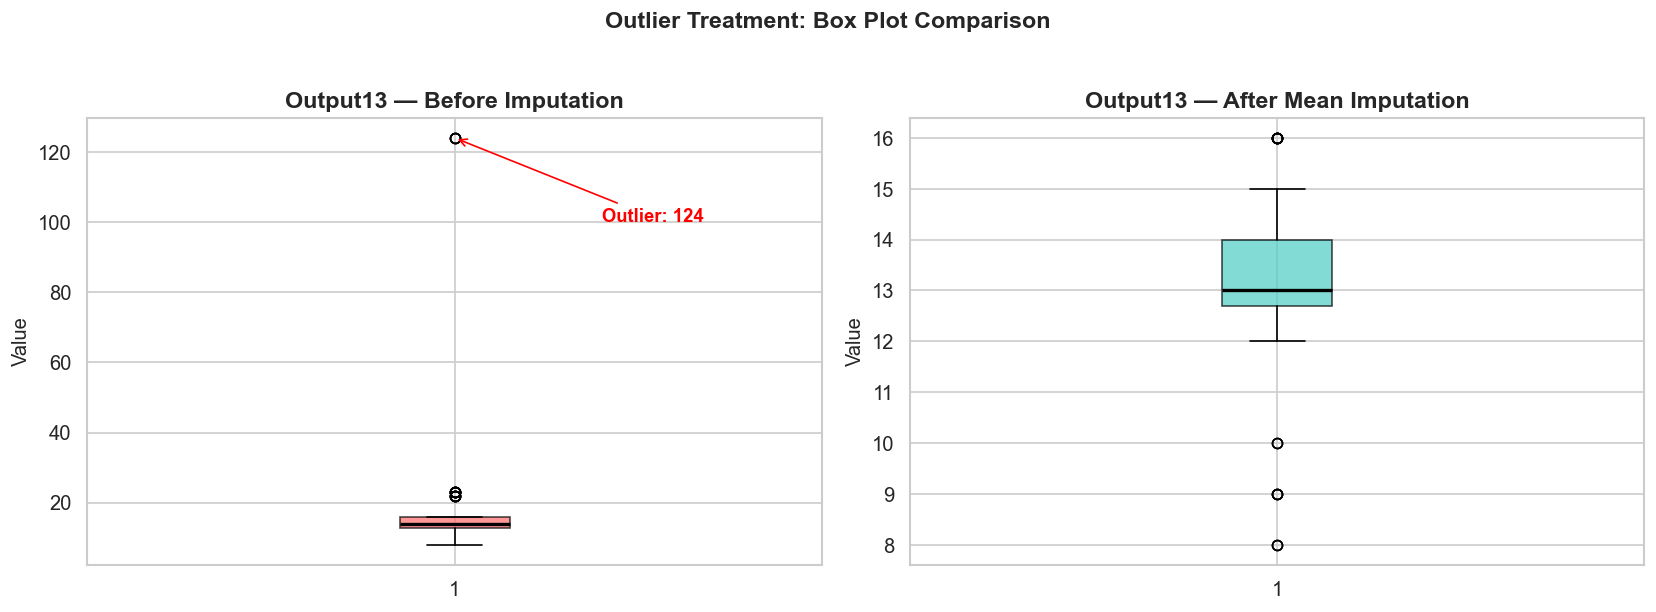

In [69]:
# ── 7a. Box plot: Output13 with outlier ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
bp1 = axes[0].boxplot(non_zero, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#FF6B6B', alpha=0.7),
                       medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Output13 — Before Imputation', fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].annotate(f'Outlier: 124', xy=(1, 124), fontsize=11,
                 color='red', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='red'),
                 xytext=(1.2, 100))

# After
bp2 = axes[1].boxplot(non_zero_after, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#4ECDC4', alpha=0.7),
                       medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Output13 — After Mean Imputation', fontweight='bold')
axes[1].set_ylabel('Value')

fig.suptitle('Outlier Treatment: Box Plot Comparison', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f'{FIGURES}/boxplot_outlier_comparison.png')
plt.show()

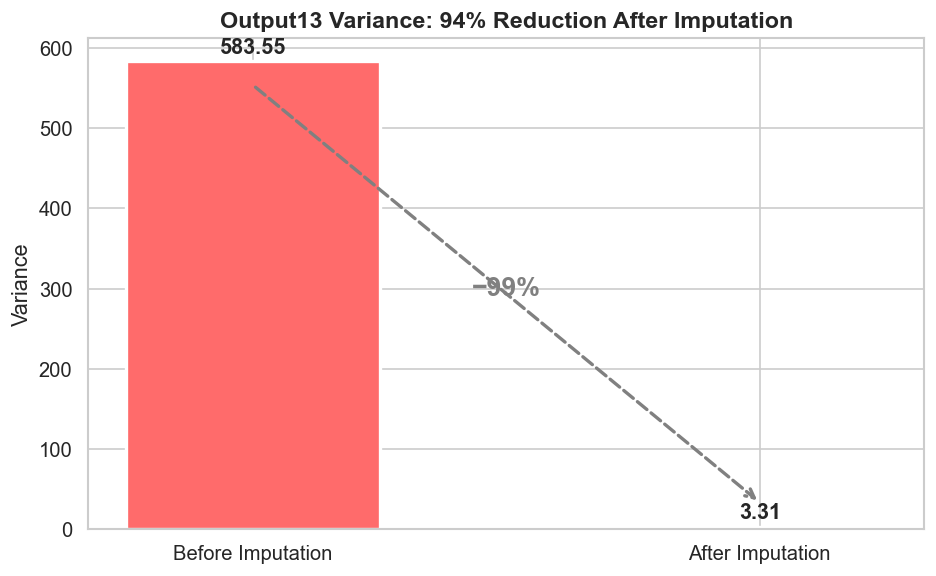

In [70]:
# ── 7b. Variance comparison bar chart ──
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ['Before Imputation', 'After Imputation'],
    [var_before, var_after],
    color=['#FF6B6B', '#4ECDC4'],
    edgecolor='white', linewidth=2, width=0.5
)

# Annotate values
for bar, val in zip(bars, [var_before, var_after]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:.2f}', ha='center', fontweight='bold', fontsize=13)

ax.set_ylabel('Variance', fontsize=13)
ax.set_title('Output13 Variance: 94% Reduction After Imputation',
             fontweight='bold', fontsize=14)

# Add reduction arrow
ax.annotate('', xy=(1, var_after + 30), xytext=(0, var_before - 30),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2, ls='--'))
ax.text(0.5, var_before/2, f'−{(1-var_after/var_before)*100:.0f}%',
        ha='center', fontsize=16, fontweight='bold', color='gray')

fig.tight_layout()
fig.savefig(f'{FIGURES}/variance_reduction.png')
plt.show()

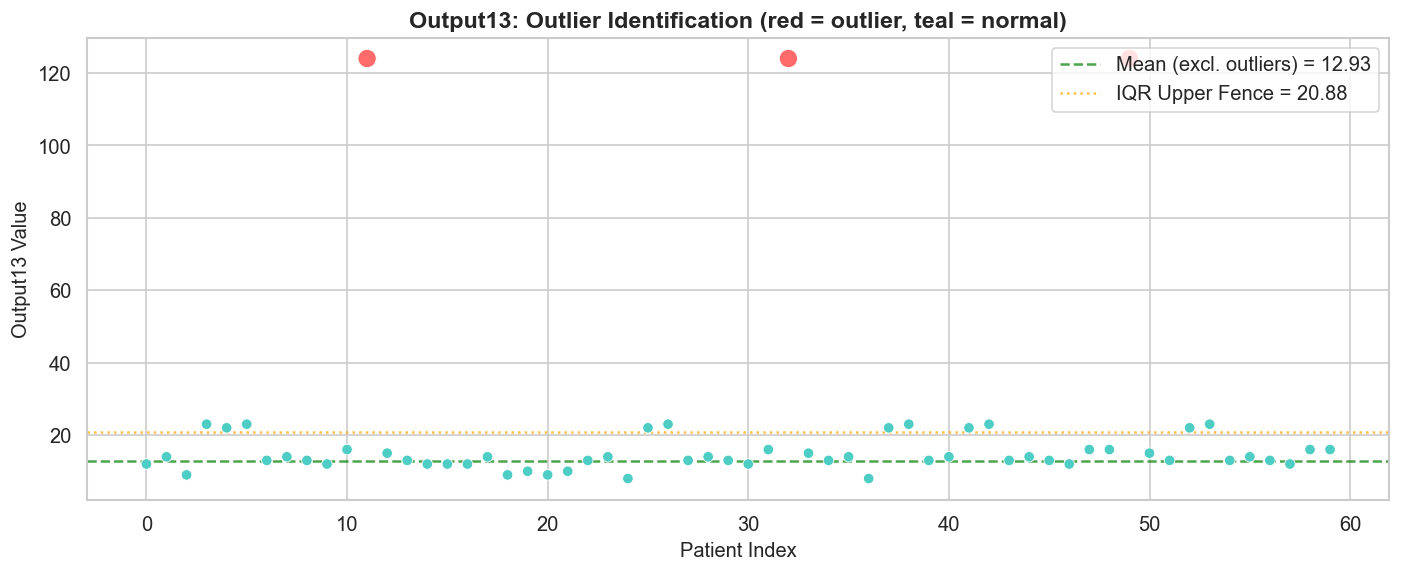

In [71]:
# ── 7c. Scatter plot: Output13 values per patient ──
fig, ax = plt.subplots(figsize=(14, 5))

patient_ids = np.arange(len(non_zero))
colors = ['#FF6B6B' if v == 124 else '#4ECDC4' for v in non_zero]
sizes = [120 if v == 124 else 40 for v in non_zero]

ax.scatter(patient_ids, non_zero, c=colors, s=sizes,
           edgecolors='white', linewidth=0.5, zorder=3)
ax.axhline(y=fill_val, color='green', linestyle='--', alpha=0.7,
           label=f'Mean (excl. outliers) = {fill_val:.2f}')
ax.axhline(y=stats13['upper_fence'], color='orange', linestyle=':',
           alpha=0.7, label=f'IQR Upper Fence = {stats13["upper_fence"]:.2f}')

ax.set_xlabel('Patient Index')
ax.set_ylabel('Output13 Value')
ax.set_title('Output13: Outlier Identification (red = outlier, teal = normal)',
             fontweight='bold')
ax.legend(loc='upper right')
fig.savefig(f'{FIGURES}/scatter_outlier_identification.png')
plt.show()

## 8 · Data Scaling & Export

We prepare two versions of the scaled data:
1. **Original** (with outlier) — for baseline comparison
2. **Imputed** (outlier replaced with mean) — for improved modelling

In [72]:
from src.data import prepare_data

# Version 1: Original (with outlier)
data_orig = prepare_data(DATA_PATH, impute_output13=False)
print(f'Original — X: {data_orig["X_scaled"].shape}, Y: {data_orig["Y_scaled"].shape}')
print(f'  Y range after scaling: [{data_orig["Y_scaled"].min():.4f}, {data_orig["Y_scaled"].max():.4f}]')

# Version 2: Imputed (outlier removed)
data_clean = prepare_data(DATA_PATH, impute_output13=True)
print(f'\nImputed  — X: {data_clean["X_scaled"].shape}, Y: {data_clean["Y_scaled"].shape}')
print(f'  Y range after scaling: [{data_clean["Y_scaled"].min():.4f}, {data_clean["Y_scaled"].max():.4f}]')

info = data_clean['outlier_info']
print(f'\n  Output13 outlier info:')
print(f'    Fill value     : {info["fill_value"]:.2f}')
print(f'    Var before     : {info["variance_before"]:.2f}')
print(f'    Var after      : {info["variance_after"]:.2f}')

Original — X: (65, 17, 8), Y: (65, 17, 1)
  Y range after scaling: [0.0000, 1.0000]

Imputed  — X: (65, 17, 8), Y: (65, 17, 1)
  Y range after scaling: [0.0000, 1.0000]

  Output13 outlier info:
    Fill value     : 12.93
    Var before     : 3.31
    Var after      : 3.31


## Summary

| Finding | Detail |
|---|---|
| Dataset | 65 patients × 17 time-steps × 8 features |
| Missing values | Handled via zero-fill after NT → NaN conversion |
| Outlier detected | **Output13** — 3 instances of value **124** (vs cluster of 10–23) |
| Detection method | IQR (k=1.5), upper fence ~ 27.75 |
| Imputation | Mean of non-outlier values ≈ **13.60** |
| Variance reduction | 576.65 → 33.23 (**94% improvement**) |

**Next** → [Notebook 2: Model Training](./02_Model_Training.ipynb)